In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import Normalize, TwoSlopeNorm


In [9]:
df = pd.read_csv('combined_output.csv')
print(df.head)

<bound method NDFrame.head of         Year    Lat    Lon  days_below_55F  days_below_32F  days_below_28F  \
0       1956  35.00 -95.00             190              50              26   
1       1956  35.00 -94.75             187              45              24   
2       1956  35.00 -94.50             190              46              25   
3       1956  35.00 -94.25             194              50              25   
4       1956  35.00 -94.00             193              52              26   
...      ...    ...    ...             ...             ...             ...   
107915  2021  25.25 -80.75               3               0               0   
107916  2021  25.00 -78.00               0               0               0   
107917  2021  24.75 -78.00               1               0               0   
107918  2021  24.50 -78.00               0               0               0   
107919  2021  24.00 -77.75               0               0               0   

        days_below_26F  annual_mi

/var/folders/3p/cs07b9rs4vx__r1rpt2kvmn00000gn/T/ipykernel_12729/2536060781.py:80: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(5, 'climate_score'))
/var/folders/3p/cs07b9rs4vx__r1rpt2kvmn00000gn/T/ipykernel_12729/2536060781.py:85: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.loc[g['climate_score'].idxmax()])


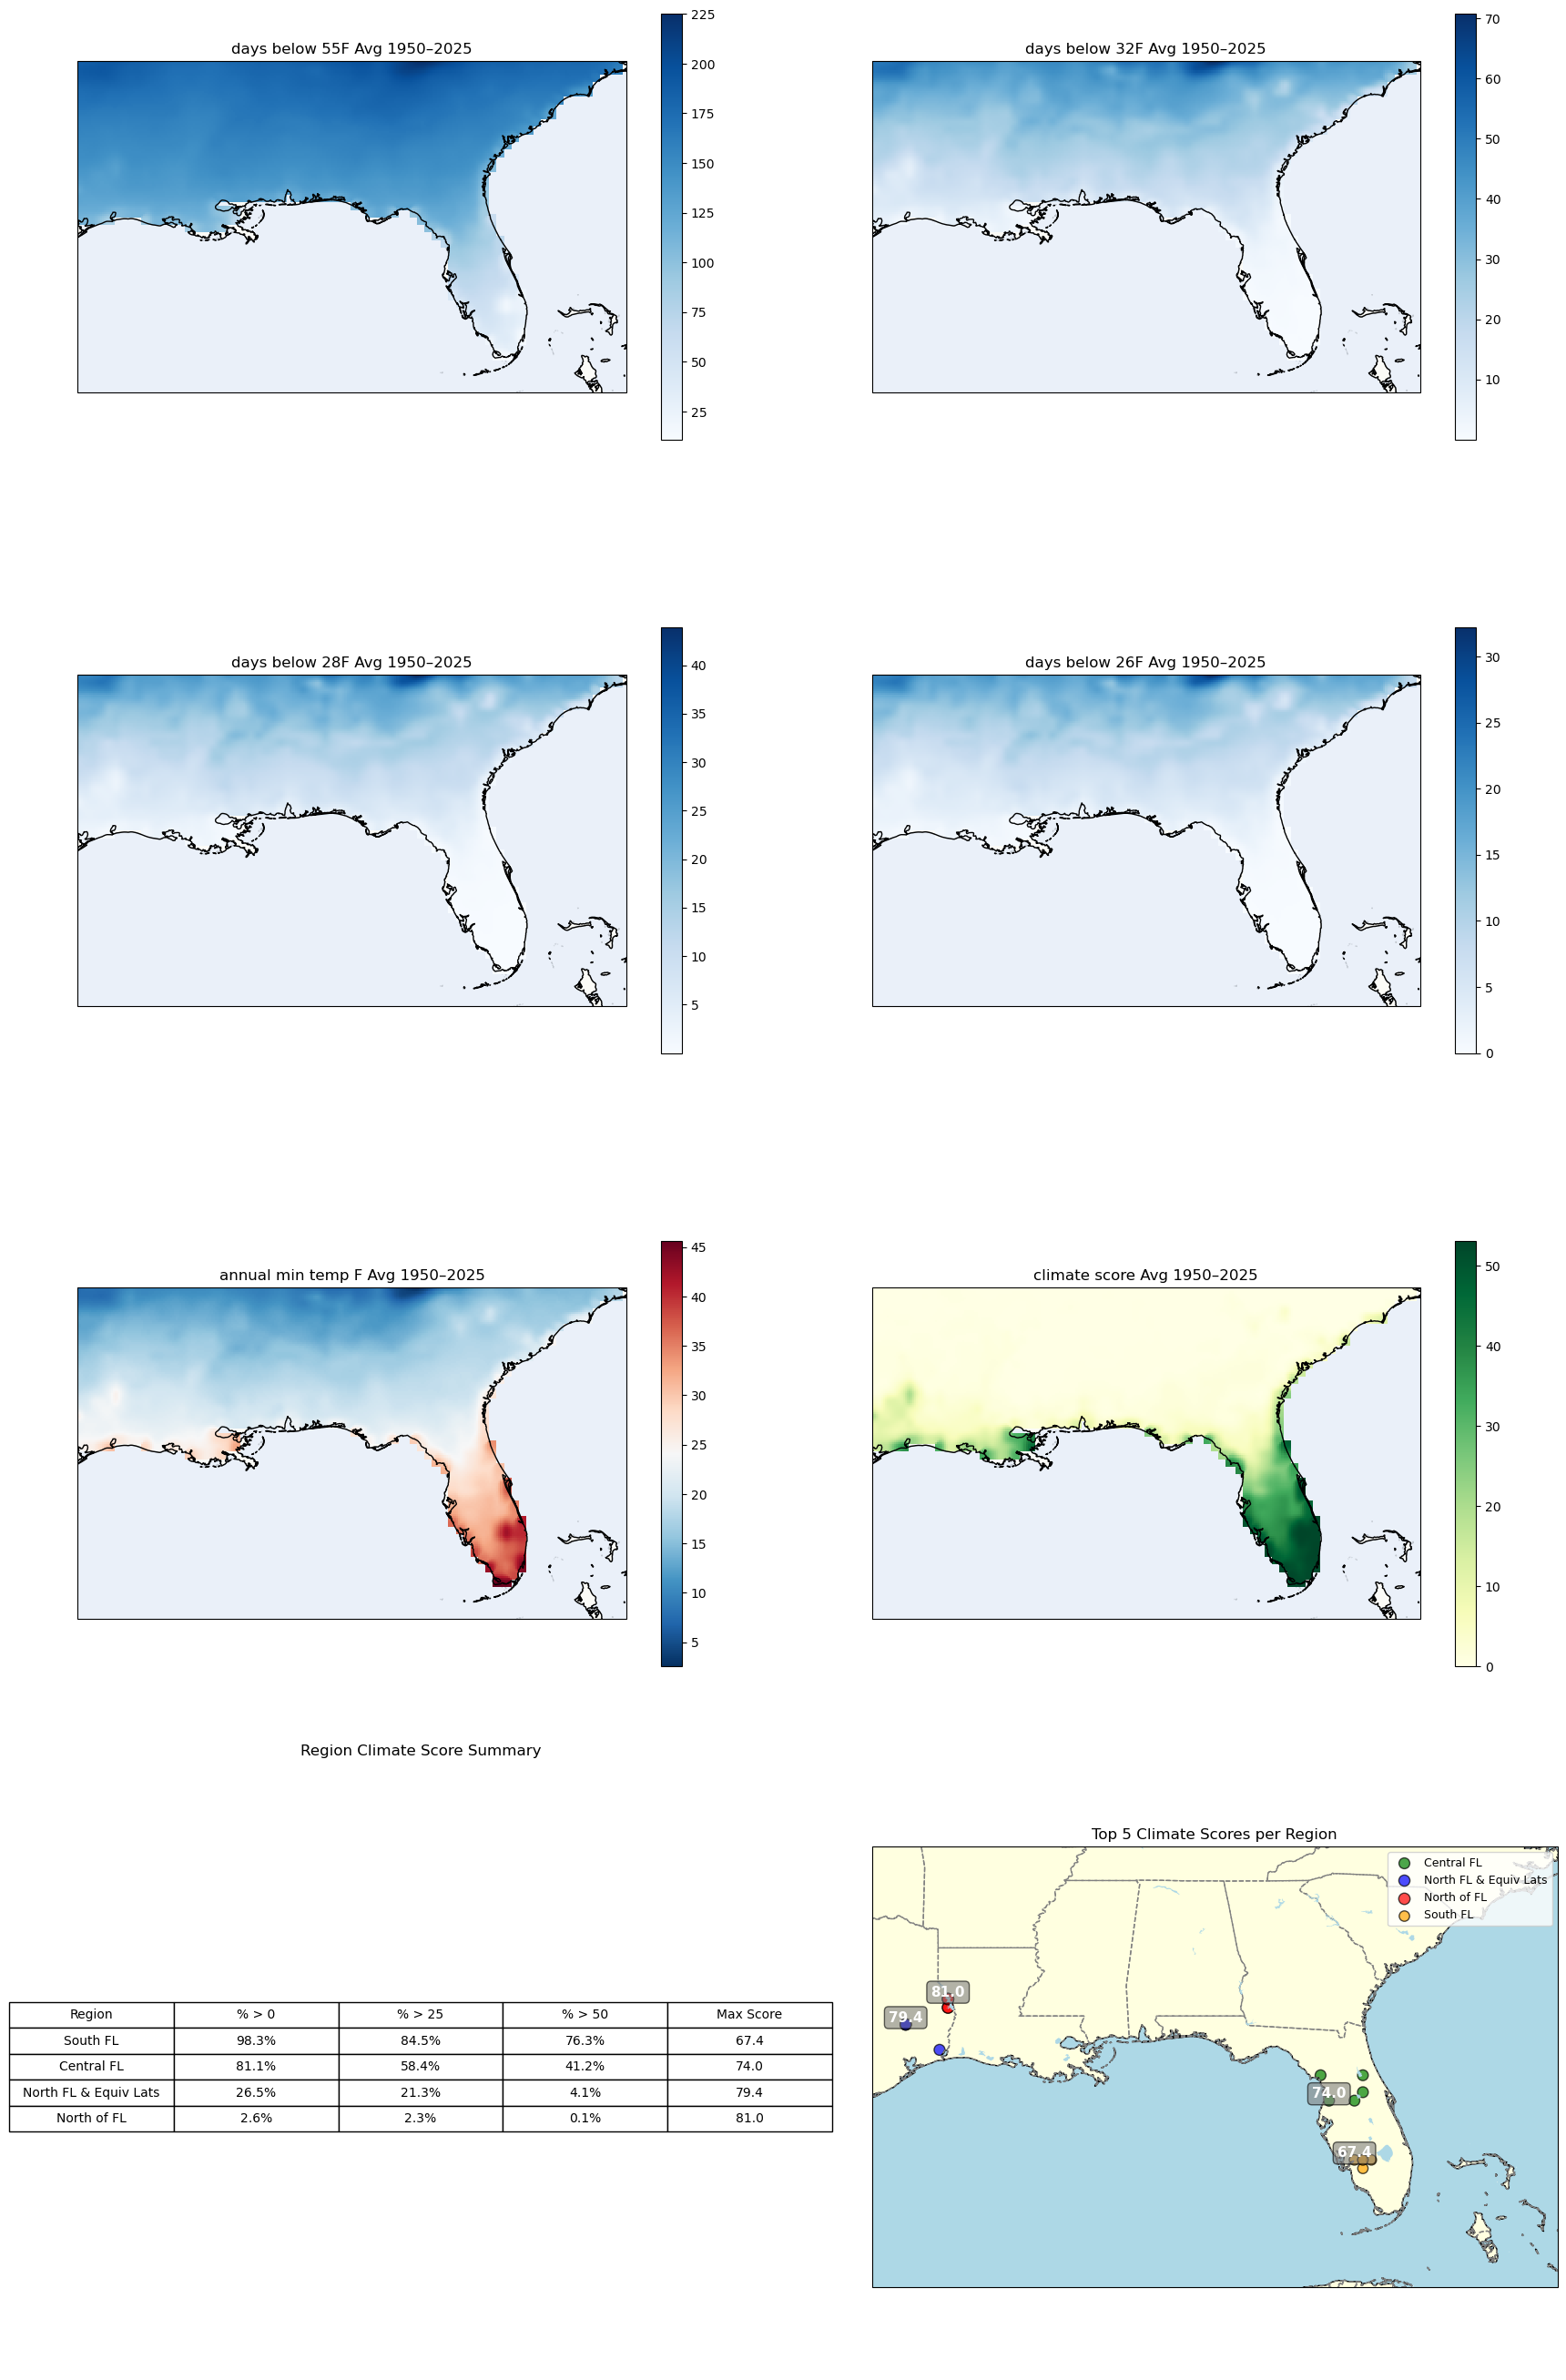

In [4]:
# --- Climate scoring function ---
    # The function assigns a score from 0–100 based on frost frequency and minimum temperatures:
        # Hard freeze disqualification: If temps drop below 26°F → score = 0.
        # Frost-free bonus: +30 points if no days below 32°F, +10 if ≤5 days.
        # Cool days reward: Adds points proportional to days below 55°F (capped at 40).
        # Extra bonus: +20 if absolutely no frost (no days below 32°F or 28°F).
        # The score is capped at 100.

def citrus_climate_score(row):
    if row['days_below_26F'] > 0 or row['annual_min_temp_F'] < 26:
        return 0
    
    score = 0
    if row['days_below_32F'] == 0:
        score += 30
    elif row['days_below_32F'] <= 5:
        score += 10
    
    score += min(row['days_below_55F'] / 5, 40)
    
    if row['days_below_32F'] == 0 and row['days_below_28F'] == 0:
        score += 20
    
    return min(score, 100)

# --- Metrics ---
metrics = [
    'days_below_55F',
    'days_below_32F',
    'days_below_28F',
    'days_below_26F',
    'annual_min_temp_F',
    'climate_score'
]

UPSAMPLE = 4
GAUSS_SIGMA = 0.8

# --- Assume df exists ---
start_year = df['Year'].min()
end_year = df['Year'].max()
df['climate_score'] = df.apply(citrus_climate_score, axis=1)

df_avg = (
    df.groupby(['Lat', 'Lon'], as_index=False)[metrics]
      .mean()
)

# --- Region classification ---
def classify_region(lat):
    if lat < 27:
        return "South FL"
    elif 27 <= lat < 29.5:
        return "Central FL"
    elif 29.5 <= lat <= 31:
        return "North FL & Equiv Lats"
    else:
        return "North of FL"

df['Region'] = df['Lat'].apply(classify_region)
region_order = ["South FL", "Central FL", "North FL & Equiv Lats", "North of FL"]

result = (
    df.groupby('Region')
      .agg(
          Percent_above_0 = ('climate_score', lambda x: (x > 0).mean() * 100),
          Percent_above_25 = ('climate_score', lambda x: (x > 25).mean() * 100),
          Percent_above_50 = ('climate_score', lambda x: (x > 50).mean() * 100),
          Max_score = ('climate_score', 'max')
      )
      .reset_index()
)

result['Region'] = pd.Categorical(result['Region'], categories=region_order, ordered=True)
result = result.sort_values('Region')

# --- Top points per region ---
top_points = (
    df.groupby('Region', group_keys=False)
      .apply(lambda g: g.nlargest(5, 'climate_score'))
)

max_points = (
    df.groupby('Region', group_keys=False)
      .apply(lambda g: g.loc[g['climate_score'].idxmax()])
)

# --- Create 4x2 grid (2 columns × 4 rows) ---
fig, axes = plt.subplots(
    4, 2, figsize=(18, 28),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
axes = axes.flatten()

# --- First 6 plots: climate metrics ---
for i, metric in enumerate(metrics):
    pivot = (
        df_avg
        .pivot(index='Lat', columns='Lon', values=metric)
        .sort_index(axis=0)
        .sort_index(axis=1)
    )
    lat = pivot.index.values
    lon = pivot.columns.values
    data = pivot.values

    interp = RegularGridInterpolator((lat, lon), data,
                                     bounds_error=False, fill_value=np.nan)
    lat_f = np.linspace(lat.min(), lat.max(), len(lat) * UPSAMPLE)
    lon_f = np.linspace(lon.min(), lon.max(), len(lon) * UPSAMPLE)
    Lon_f, Lat_f = np.meshgrid(lon_f, lat_f)
    pts = np.stack([Lat_f.ravel(), Lon_f.ravel()], axis=1)
    data_f = interp(pts).reshape(Lat_f.shape)

    if GAUSS_SIGMA > 0:
        mask = np.isnan(data_f)
        tmp = data_f.copy(); tmp[mask] = 0.0
        w = (~mask).astype(float)
        tmp_blur = gaussian_filter(tmp, sigma=GAUSS_SIGMA)
        w_blur = gaussian_filter(w, sigma=GAUSS_SIGMA)
        with np.errstate(invalid='ignore', divide='ignore'):
            data_f = tmp_blur / w_blur
        data_f[w_blur == 0] = np.nan

    if metric.startswith('days_below'):
        cmap = 'Blues'
    elif metric == 'annual_min_temp_F':
        cmap = 'RdBu_r'
    elif metric == 'climate_score':
        cmap = 'YlGn'
    else:
        cmap = 'coolwarm'
    norm = Normalize(vmin=np.nanmin(data_f), vmax=np.nanmax(data_f))

    ax = axes[i]
    mesh = ax.pcolormesh(Lon_f, Lat_f, data_f,
                         cmap=cmap, shading='auto',
                         transform=ccrs.PlateCarree(), norm=norm)
    ax.coastlines(); ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, edgecolor='black', alpha=0.2)
    ax.add_feature(cfeature.OCEAN, alpha=0.2)
    ax.set_title(f"{metric.replace('_',' ')} Avg {start_year}–{end_year}", fontsize=12)
    plt.colorbar(mesh, ax=ax, orientation='vertical', shrink=0.7)

# --- Seventh plot: region summary as table ---
ax = axes[6]
ax.remove()  # remove projection
ax = fig.add_subplot(4, 2, 7)  # re-add as normal subplot

# Hide axes
ax.axis('off')

# Format percent columns to one decimal place with %
formatted = result.copy()
for col in ['Percent_above_0','Percent_above_25','Percent_above_50']:
    formatted[col] = formatted[col].map(lambda x: f"{x:.1f}%")

# Build table from formatted DataFrame
table = ax.table(
    cellText=formatted[['Region','Percent_above_0','Percent_above_25','Percent_above_50','Max_score']].values,
    colLabels=['Region','% > 0','% > 25','% > 50','Max Score'],
    cellLoc='center',
    loc='center'
)

# Style table
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

ax.set_title("Region Climate Score Summary", fontsize=12)



# --- Eighth plot: top points scatter map ---
ax = axes[7]
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linestyle='--', edgecolor='gray')
ax.add_feature(cfeature.LAND, facecolor='lightyellow')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.LAKES, facecolor='lightblue')

colors = {
    "South FL": "orange",
    "Central FL": "green",
    "North FL & Equiv Lats": "blue",
    "North of FL": "red"
}

for region, group in top_points.groupby('Region'):
    ax.scatter(group['Lon'], group['Lat'],
               s=group['climate_score'],
               c=colors[region], label=region,
               alpha=0.7, edgecolor='black',
               transform=ccrs.PlateCarree())

for _, row in max_points.iterrows():
    ax.text(row['Lon'], row['Lat'], f"{row['climate_score']:.1f}",
            fontsize=11, ha='center', va='bottom',
            fontweight='bold', color='white',
            bbox=dict(facecolor='grey', alpha=0.6, boxstyle='round,pad=0.3'),
            transform=ccrs.PlateCarree())

lat_min, lat_max = df['Lat'].min()-1, df['Lat'].max()+1
lon_min, lon_max = df['Lon'].min()-1, df['Lon'].max()+1
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.set_title("Top 5 Climate Scores per Region", fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout(pad=4.0)
plt.show()
